In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"

In [ ]:
X_test = np.load(os.path.join(DATASET_PATH, "X_test.npy"))
Y_test = np.load(os.path.join(DATASET_PATH, "Y_test.npy"))

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_test: (341, 256, 256, 3)
Y_test: (341, 256, 256, 1)


In [ ]:
# ============================================
# Dice Coefficient
# ============================================

def dice_coefficient(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)

    return (
        2.0 * intersection + 1.0
    ) / (
        K.sum(y_true) +
        K.sum(y_pred) +
        1.0
    )


# ============================================
# Dice Loss
# ============================================

def dice_loss(y_true, y_pred):

    return 1.0 - dice_coefficient(y_true, y_pred)

# ============================================
# IoU Score
# ============================================

def iou_score(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)

    union = (
        K.sum(y_true)
        +
        K.sum(y_pred)
        -
        intersection
    )

    return (
        intersection + 1.0
    ) / (
        union + 1.0
    )


# ============================================
# BCE + Dice Loss
# ============================================

bce = tf.keras.losses.BinaryCrossentropy()

def combined_loss(y_true, y_pred):

    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [ ]:
cnn_model = load_model(
    os.path.join(DATASET_PATH, "basic_cnn_best.keras"),
    custom_objects={
        "dice_coefficient": dice_coefficient,
        "dice_loss": dice_loss,
        "iou_score": iou_score,
        "combined_loss": combined_loss
    }
)

unet_model = load_model(
    os.path.join(DATASET_PATH, "enhanced_unet_best.keras"),
    custom_objects={
        "dice_coefficient": dice_coefficient,
        "dice_loss": dice_loss,
        "iou_score": iou_score,
        "combined_loss": combined_loss
    }
)

print("✅ CNN Model Loaded Successfully")
print("✅ U-Net Model Loaded Successfully")

✅ CNN Model Loaded Successfully
✅ U-Net Model Loaded Successfully


In [ ]:
# Number of test images to visualize
num_samples = 5

# Randomly select test images
indices = np.random.choice(len(X_test), num_samples, replace=False)

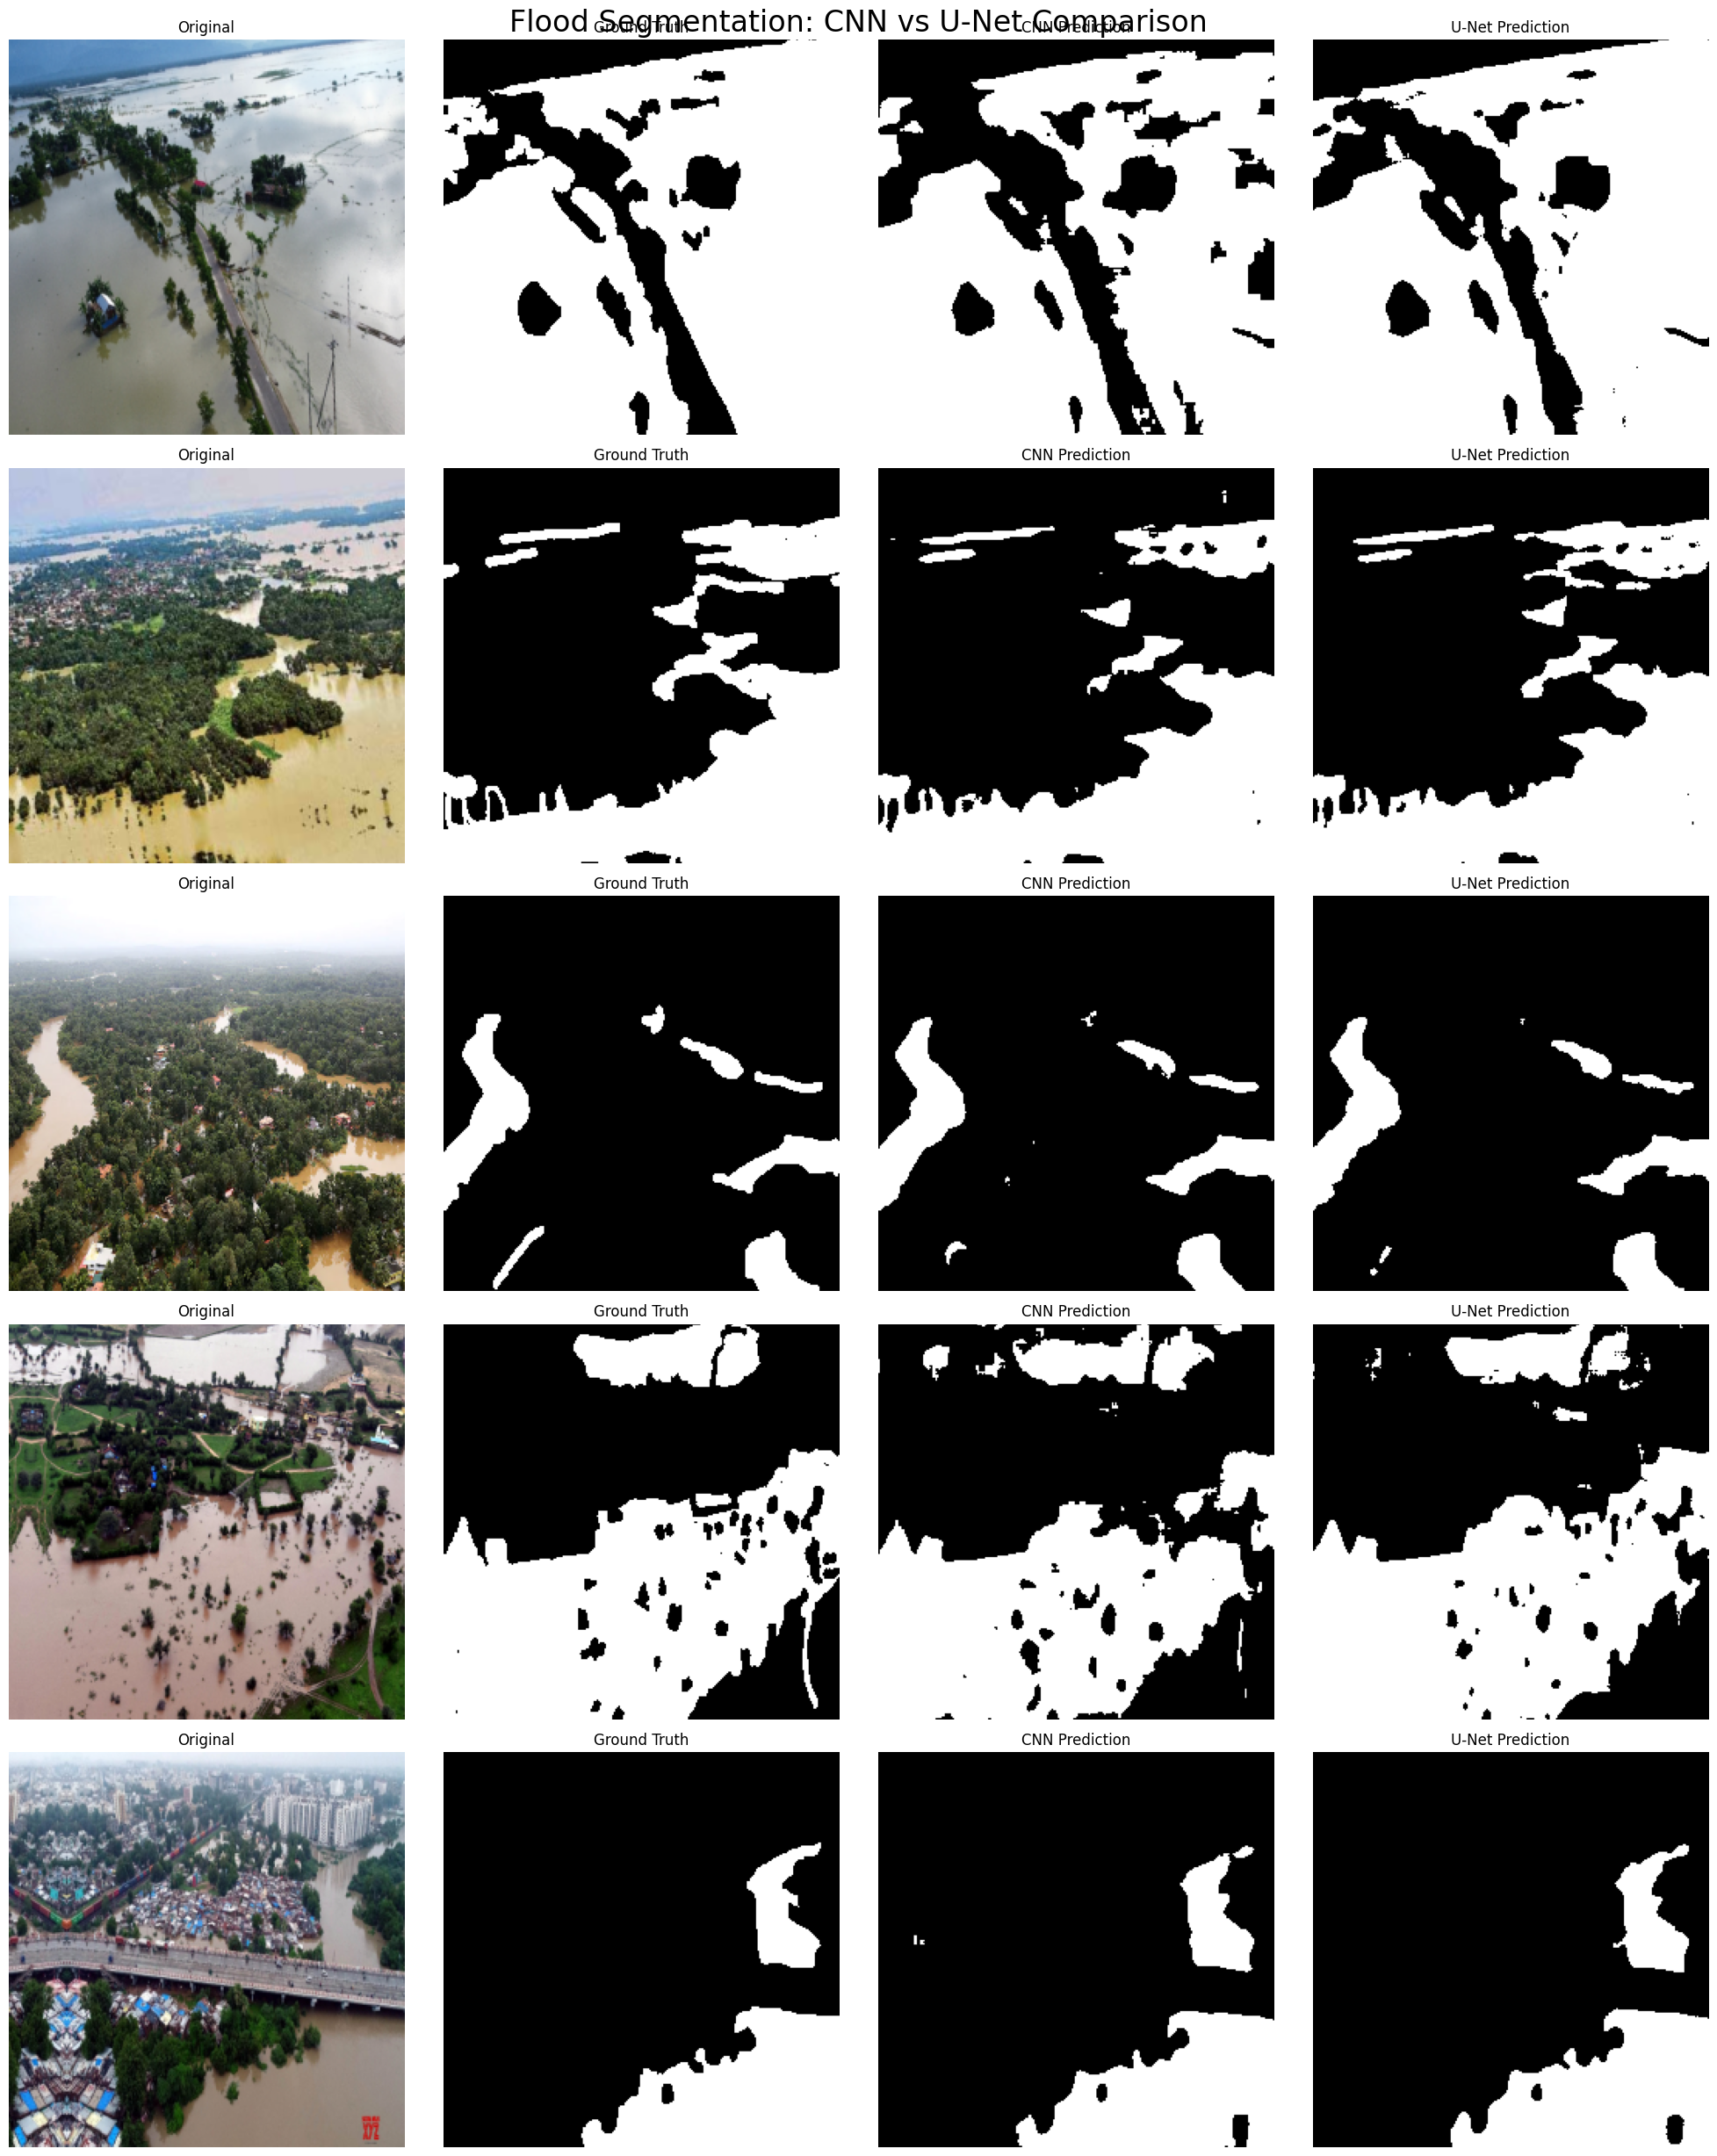

In [ ]:
plt.figure(figsize=(20, num_samples * 5))

for i, idx in enumerate(indices):

    image = X_test[idx]
    true_mask = Y_test[idx]

    # CNN Prediction
    cnn_pred = cnn_model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0]

    cnn_pred = (cnn_pred > 0.5).astype(np.uint8)

    # U-Net Prediction
    unet_pred = unet_model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0]

    unet_pred = (unet_pred > 0.5).astype(np.uint8)

    # Original Image
    plt.subplot(num_samples, 4, 4*i + 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    # Ground Truth
    plt.subplot(num_samples, 4, 4*i + 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # CNN Prediction
    plt.subplot(num_samples, 4, 4*i + 3)
    plt.imshow(cnn_pred.squeeze(), cmap="gray")
    plt.title("CNN Prediction")
    plt.axis("off")

    # U-Net Prediction
    plt.subplot(num_samples, 4, 4*i + 4)
    plt.imshow(unet_pred.squeeze(), cmap="gray")
    plt.title("U-Net Prediction")
    plt.axis("off")

plt.suptitle("Flood Segmentation: CNN vs U-Net Comparison", fontsize=24)
plt.tight_layout()
plt.savefig("Segmentation_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()